In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft2, fftshift
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Konfiguracja Kaggle (wymaga pliku kaggle.json lub ustawienia tokenu)
# os.environ['KAGGLE_API_TOKEN'] = "TWÓJ_TOKEN_JEŚLI_POTRZEBNY"

!kaggle datasets download -d shreyamishra0307/realvsfake
!unzip -q realvsfake.zip -d data



'kaggle' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


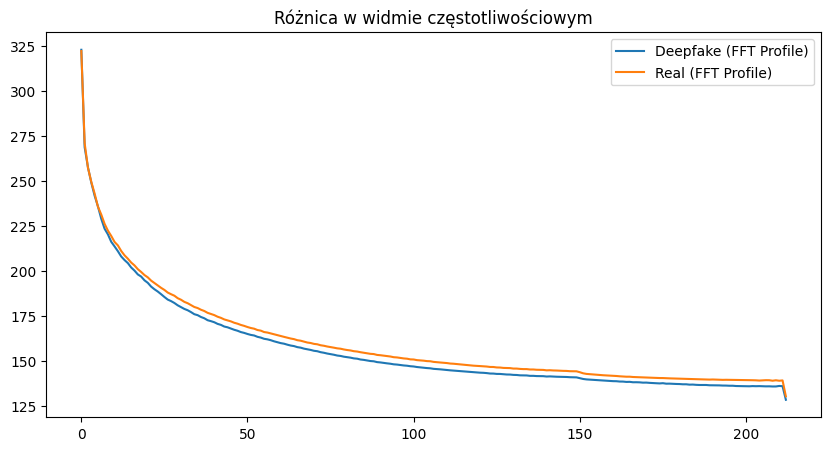

Accuracy: 0.775
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       189
           1       0.80      0.76      0.78       211

    accuracy                           0.78       400
   macro avg       0.78      0.78      0.77       400
weighted avg       0.78      0.78      0.78       400



e:\Studia\DL-deepfake-detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
def radial_profile(data, center):
    y, x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / nr
    return radialprofile

def extract_fft_features(image_path, size=300):
    # Wczytanie obrazu w skali szarości
    img = cv2.imread(image_path, 0)
    if img is None: return None
    img = cv2.resize(img, (size, size))

    # Obliczenie FFT
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift))

    # Średnia azymutalna (skalowanie widma do 1D)
    center = (int(size/2), int(size/2))
    features = radial_profile(magnitude_spectrum, center)

    return features




data = []
labels = []
limit = 1000 # Przykładowy limit dla demonstracji

base_path = "whole/train"
categories = ["fake", "real"]

for category in categories:
    folder = os.path.join(base_path, category)
    label = 0 if category == "fake" else 1
    count = 0
    for filename in os.listdir(folder):
        if count >= limit: break
        feat = extract_fft_features(os.path.join(folder, filename))
        if feat is not None:
            data.append(feat)
            labels.append(label)
            count += 1

X = np.array(data)
y = np.array(labels)



plt.figure(figsize=(10, 5))
fake_mean = np.mean(X[y==0], axis=0)
real_mean = np.mean(X[y==1], axis=0)

plt.plot(fake_mean, label="Deepfake (FFT Profile)")
plt.plot(real_mean, label="Real (FFT Profile)")
plt.legend()
plt.title("Różnica w widmie częstotliwościowym")
plt.show()



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds)}")
print(classification_report(y_test, preds))


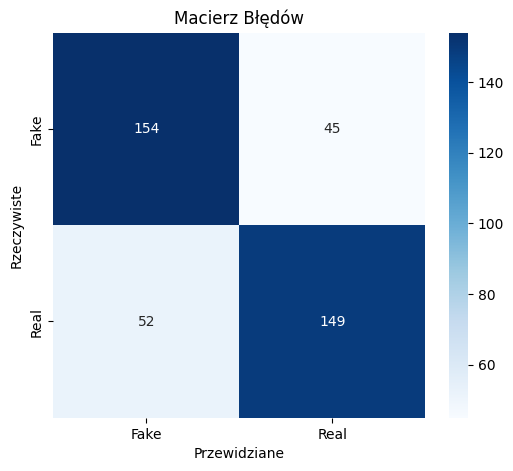

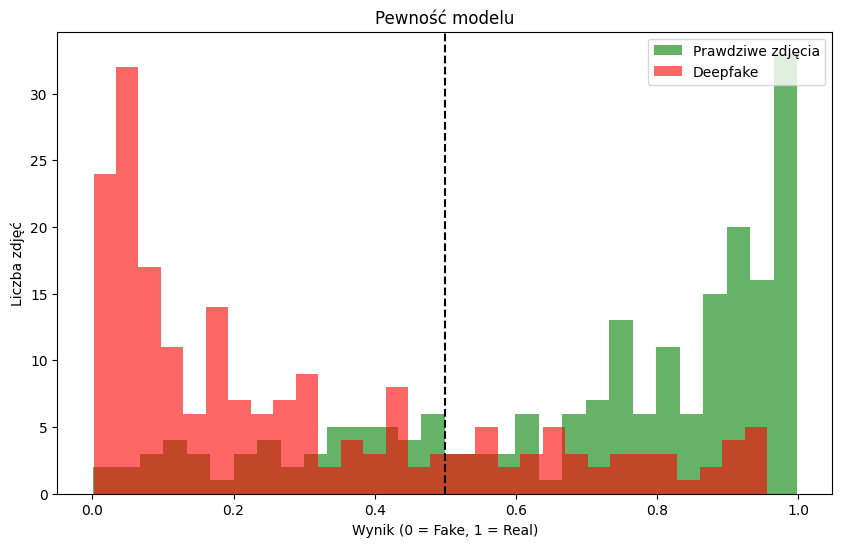

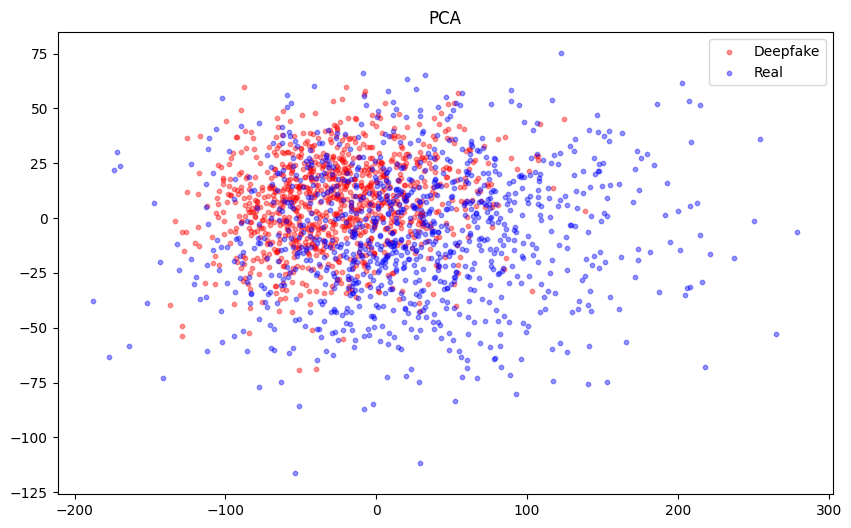

In [5]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA




from sklearn.preprocessing import StandardScaler

# 1. Skalowanie - to jest KLUCZOWE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Podział (dodaj random_state, żeby wyniki były powtarzalne)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Trening
clf = LogisticRegression(max_iter=2000) # Zwiększ iteracje
clf.fit(X_train, y_train)

# 4. Predykcja
preds = clf.predict(X_test)


def visualize_process(image_path, title="Analiza"):
    img = cv2.imread(image_path, 0)
    img_res = cv2.resize(img, (300, 300))


    f = np.fft.fft2(img_res)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
    profile = radial_profile(magnitude_spectrum, (150, 150))

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img_res, cmap='gray')
    plt.title(f"Oryginał ({title})")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(magnitude_spectrum, cmap='magma')
    plt.title("Widmo FFT 2D")

    plt.subplot(1, 3, 3)
    plt.plot(profile)
    plt.title("Profil 1D (Cechy dla modelu)")
    plt.grid(alpha=0.3)
    plt.show()




# --- 2. MACIERZ BŁĘDÓW
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Przewidziane')
plt.ylabel('Rzeczywiste')
plt.title('Macierz Błędów')
plt.show()



probs = clf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 6))
plt.hist(probs[y_test==1], bins=30, alpha=0.6, label='Prawdziwe zdjęcia', color='green')
plt.hist(probs[y_test==0], bins=30, alpha=0.6, label='Deepfake', color='red')
plt.axvline(0.5, color='black', linestyle='--') # Granica decyzji
plt.title('Pewność modelu')
plt.xlabel('Wynik (0 = Fake, 1 = Real)')
plt.ylabel('Liczba zdjęć')
plt.legend()
plt.show()




pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], c='red', label='Deepfake', alpha=0.4, s=10)
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], c='blue', label='Real', alpha=0.4, s=10)
plt.title('PCA')
plt.legend()
plt.show()

F1-Score (dla klasy Real): 0.7544

--- ANALIZA PRZEUCZENIA ---
Accuracy na zbiorze TRENINGOWYM: 0.8356
Accuracy na zbiorze TESTOWYM:    0.7575
WERDYKT: Model jest stabilny. Różnica między treningiem a testem jest mała.


e:\Studia\DL-deepfake-detection\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "e:\Studia\DL-deepfake-detection\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "e:\Studia\DL-deepfake-detection\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Studia\DL-deepfake-detection\.venv\Lib\site-packages\sklearn\linear_m

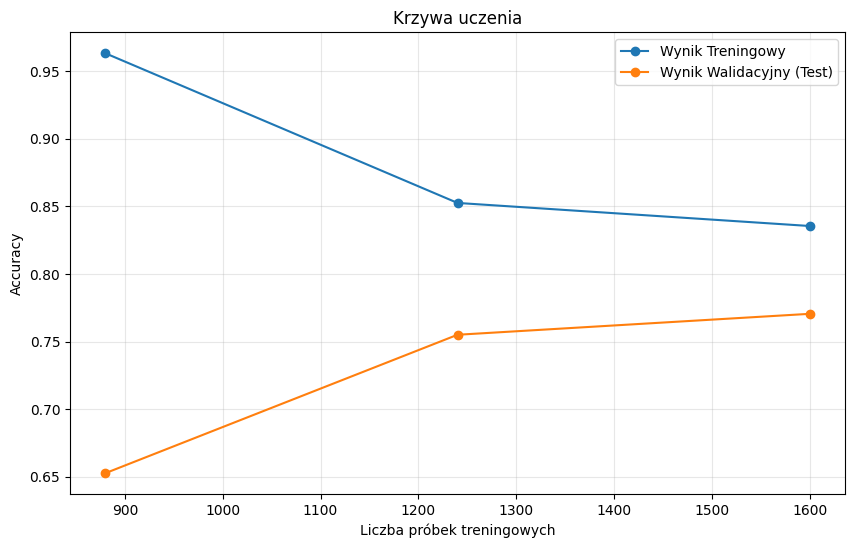

In [6]:
from sklearn.metrics import f1_score
from sklearn.model_selection import learning_curve

# --- 1. OBLICZENIE F1-SCORE ---
f1 = f1_score(y_test, preds)
print(f"F1-Score (dla klasy Real): {f1:.4f}")

# --- 2. SPRAWDZENIE PRZEUCZENIA (OVERFITTING) ---
train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)

print("\n--- ANALIZA PRZEUCZENIA ---")
print(f"Accuracy na zbiorze TRENINGOWYM: {train_acc:.4f}")
print(f"Accuracy na zbiorze TESTOWYM:    {test_acc:.4f}")

if train_acc > test_acc + 0.1:
    print("WERDYKT: Model jest PRZEUCZONY (Overfitting). Pamięta dane, ale słabo generalizuje.")
else:
    print("WERDYKT: Model jest stabilny. Różnica między treningiem a testem jest mała.")

# --- 3. WYKRES KRZYWEJ UCZENIA (LEARNING CURVE) ---
# Pokazuje jak model uczy się wraz z przyrostem danych
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=2000), X_scaled, y, cv=5, scoring='accuracy', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Wynik Treningowy', marker='o')
plt.plot(train_sizes, test_mean, label='Wynik Walidacyjny (Test)', marker='o')
plt.title('Krzywa uczenia')
plt.xlabel('Liczba próbek treningowych')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
import joblib

joblib.dump(clf, "fft_logreg_model.pkl")
joblib.dump(scaler, "fft_scaler.pkl")
print("Model zapisany: fft_logreg_model.pkl")
print("Scaler zapisany: fft_scaler.pkl")


Model zapisany: fft_logreg_model.pkl
Scaler zapisany: fft_scaler.pkl
